In [24]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit

df = pd.read_csv('cricket_features_with_defense_final.csv')

res_map = {-1: 0, 0: 1, 1: 2}
df['Result_Encoded'] = df['Result'].map(res_map)

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df, groups=df['Match_ID']))
test_df = df.iloc[test_idx].copy()

print(f"Test set contains {test_df['Match_ID'].nunique()} unique matches.")

Test set contains 180 unique matches.


In [25]:
model = joblib.load('cricket_model_optuna4.pkl')

feature_cols = [col for col in test_df.columns if col not in ['Match_ID', 'Date', 'Venue', 'Reference_Team', 'Opponent', 'Result', 'Result_Encoded']]

probs = model.predict_proba(test_df[feature_cols])
test_df['Prob_Loss'] = probs[:, 0]
test_df['Prob_Draw'] = probs[:, 1]
test_df['Prob_Win'] = probs[:, 2]
print("Probabilities generated successfully.")

Probabilities generated successfully.


In [26]:
scenarios = {'Collapse': None, 'Recovery': None, 'Draw': None}
scores = {'Collapse': -1.0, 'Recovery': -1.0, 'Draw': -1.0}

unique_test_matches = test_df['Match_ID'].unique()

for m_id in unique_test_matches:
    match_data = test_df[test_df['Match_ID'] == m_id].sort_values('Overs_Remaining', ascending=False)
    match_data = match_data.dropna(subset=['Result_Encoded', 'Prob_Win', 'Prob_Loss', 'Prob_Draw'])

    if len(match_data) < 15: continue

    actual_res = match_data['Result_Encoded'].iloc[-1]

    if actual_res == 0:
        score = match_data['Prob_Win'].max() - match_data['Prob_Win'].iloc[-1]
        if score > scores['Collapse']:
            scores['Collapse'] = score
            scenarios['Collapse'] = m_id

    if actual_res == 2:
        score = match_data['Prob_Loss'].max() + match_data['Prob_Win'].iloc[-1]
        if score > scores['Recovery']:
            scores['Recovery'] = score
            scenarios['Recovery'] = m_id

    if actual_res == 1:
        score = match_data['Prob_Draw'].iloc[-1]
        if score > scores['Draw']:
            scores['Draw'] = score
            scenarios['Draw'] = m_id

print("Identified Match IDs for Scenarios (Interval 15):", scenarios)

Identified Match IDs for Scenarios (Interval 15): {'Collapse': np.int64(1876), 'Recovery': np.int64(1636), 'Draw': np.int64(1917)}


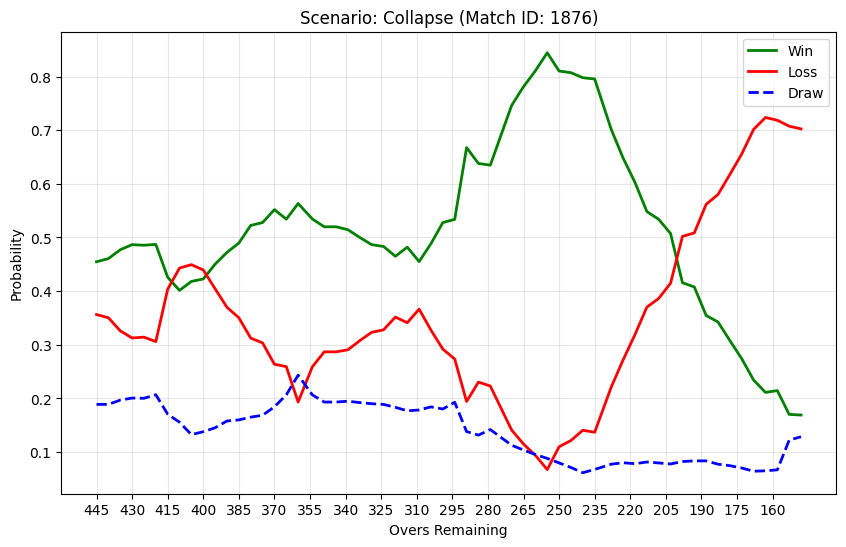

Saved plot as collapse_v15.png


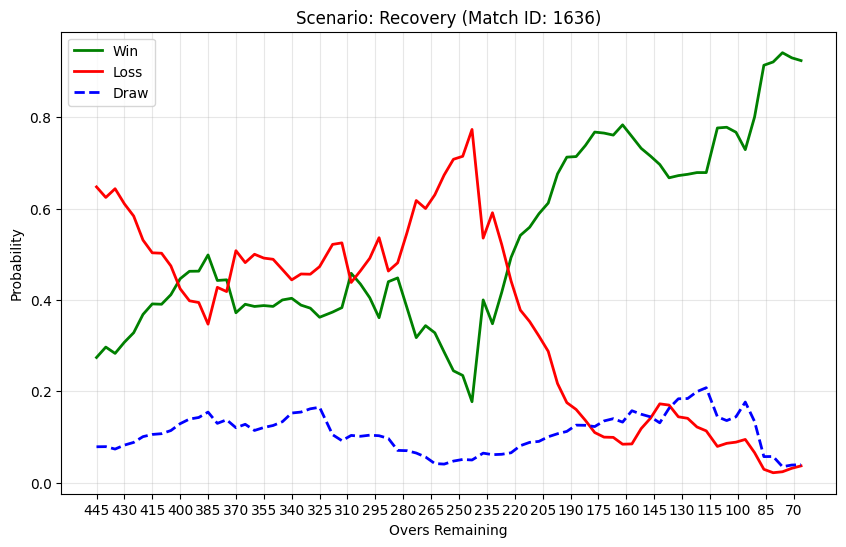

Saved plot as recovery_v15.png


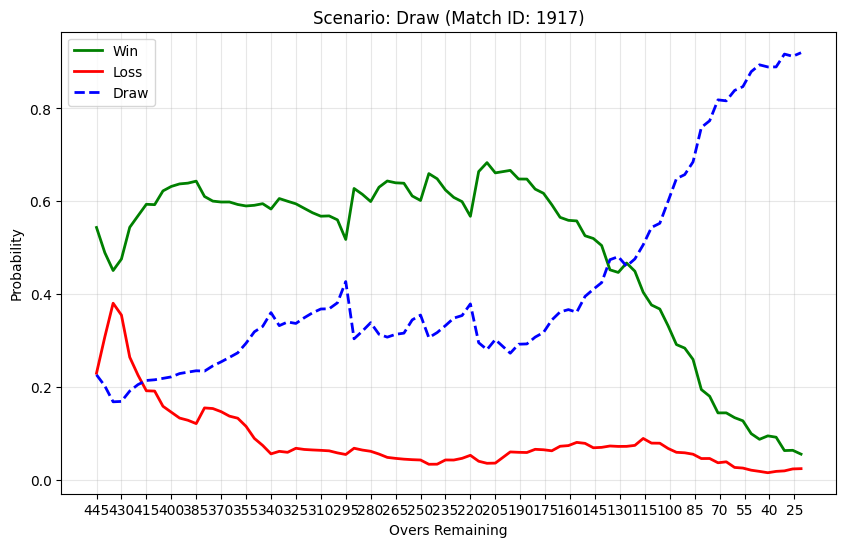

Saved plot as draw_v15.png


In [27]:
import matplotlib.pyplot as plt

def plot_match_scenario(match_id, scenario_name):
    if match_id is None:
        print(f"No match found for {scenario_name}")
        return

    data = test_df[test_df['Match_ID'] == match_id].sort_values('Overs_Remaining', ascending=False)

    plt.figure(figsize=(10, 6))
    plt.plot(data['Overs_Remaining'], data['Prob_Win'], color='green', label='Win', linewidth=2)
    plt.plot(data['Overs_Remaining'], data['Prob_Loss'], color='red', label='Loss', linewidth=2)
    plt.plot(data['Overs_Remaining'], data['Prob_Draw'], color='blue', linestyle='--', label='Draw', linewidth=2)

    plt.gca().invert_xaxis()

    min_overs = data['Overs_Remaining'].min()
    max_overs = data['Overs_Remaining'].max()
    ticks = np.arange(max_overs, min_overs - 1, -15)
    plt.xticks(ticks)

    plt.title(f"Scenario: {scenario_name} (Match ID: {match_id})")
    plt.xlabel("Overs Remaining")
    plt.ylabel("Probability")
    plt.legend()
    plt.grid(True, alpha=0.3)

    filename = f"{scenario_name.lower().replace(' ', '_')}_v15.png"
    plt.savefig(filename)
    plt.show()
    print(f"Saved plot as {filename}")

for name, m_id in scenarios.items():
    plot_match_scenario(m_id, name)

In [28]:
import pandas as pd

train_match_ids = df.iloc[train_idx]['Match_ID'].unique()
test_match_ids = df.iloc[test_idx]['Match_ID'].unique()

scenarios_to_check = {
    'Collapse': 1876,
    'Recovery': 1636,
    'Draw': 1917
}

print("--- Data Leakage Verification ---")
for name, m_id in scenarios_to_check.items():
    is_in_test = m_id in test_match_ids
    is_in_train = m_id in train_match_ids
    status = "VALID (In Test Set)" if (is_in_test and not is_in_train) else "INVALID (Data Leakage!)"
    print(f"{name} (ID: {m_id}): {status}")

print(f"\nTotal Unique Matches in Test Set: {len(test_match_ids)}")
print(f"Total Unique Matches in Train Set: {len(train_match_ids)}")

--- Data Leakage Verification ---
Collapse (ID: 1876): VALID (In Test Set)
Recovery (ID: 1636): VALID (In Test Set)
Draw (ID: 1917): VALID (In Test Set)

Total Unique Matches in Test Set: 180
Total Unique Matches in Train Set: 718
